In [30]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator # for reducer func

In [31]:
load_dotenv()

True

In [32]:
model = ChatGoogleGenerativeAI(model = 'gemini-2.5-flash')

In [33]:
class EvaluateSchema(BaseModel):
    feedback: str = Field(description = 'Detailed Feedback for the essay')
    score: int = Field(description = 'Score out of 10', ge = 0, le = 10)

In [34]:
structured_model = model.with_structured_output(EvaluateSchema)

In [35]:
class UPSCState(TypedDict):
    essay: str
    language_fb: str
    analysis_fb: str
    clarity_fb: str
    overall_fb: str
    individual_scores : Annotated[list[int], operator.add]
    avg_score : float    

In [36]:
def eval_lang(state: UPSCState) -> UPSCState:
    prompt = f'Evaluate the given {state["essay"]} on the quality of language and provide a detailed feedback and a score out of 10'
    output = structured_model.invoke(prompt)
    
    return {'language_fb': output.feedback, 'individual_scores': [output.score]}

In [37]:
def eval_analysis(state: UPSCState) -> UPSCState:
    prompt = f'Evaluate the given {state["essay"]} on the depth of analysis and provide a detailed feedback and a score out of 10'
    output = structured_model.invoke(prompt)
    
    return {'analysis_fb': output.feedback, 'individual_scores': [output.score]}

In [38]:
def eval_clarity(state: UPSCState) -> UPSCState:
    prompt = f'Evaluate the given {state["essay"]} on clarity of thought and provide a detailed feedback and a score out of 10'
    output = structured_model.invoke(prompt)
    
    return {'clarity_fb': output.feedback, 'individual_scores': [output.score]}

In [39]:
def final_eval(state: UPSCState) -> UPSCState:
        prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state["language_fb"]} \n depth of analysis feedback - {state["analysis_fb"]} \n clarity of thought feedback - {state["clarity_fb"]}'
        final_eval = model.invoke(prompt).content
        
        avg_score = sum(state["individual_scores"]) / len(state["individual_scores"])
        
        return {'overall_fb': final_eval, 'avg_score': avg_score}

In [40]:
graph = StateGraph(UPSCState)

graph.add_node('eval_lang', eval_lang)
graph.add_node('eval_analysis', eval_analysis)
graph.add_node('eval_clarity', eval_clarity)
graph.add_node('final_eval', final_eval)

graph.add_edge(START, 'eval_lang')
graph.add_edge(START, 'eval_analysis')
graph.add_edge(START, 'eval_clarity')

graph.add_edge('eval_lang', 'final_eval')
graph.add_edge('eval_analysis', 'final_eval')
graph.add_edge('eval_clarity', 'final_eval')

graph.add_edge('final_eval', END)

workflow = graph.compile()


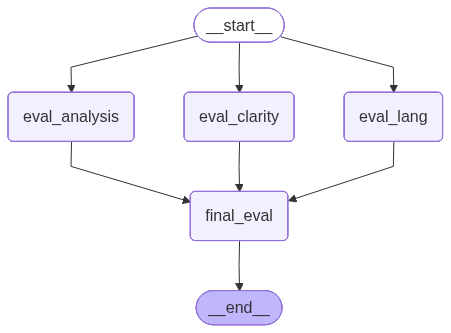

In [41]:
workflow

In [42]:
essay2 = """India and AI Time

Now world change very fast because new tech call Artificial Intel… something (AI). India also want become big in this AI thing. If work hard, India can go top. But if no careful, India go back.

India have many good. We have smart student, many engine-ear, and good IT peoples. Big company like TCS, Infosys, Wipro already use AI. Government also do program “AI for All”. It want AI in farm, doctor place, school and transport.

In farm, AI help farmer know when to put seed, when rain come, how stop bug. In health, AI help doctor see sick early. In school, AI help student learn good. Government office use AI to find bad people and work fast.

But problem come also. First is many villager no have phone or internet. So AI not help them. Second, many people lose job because AI and machine do work. Poor people get more bad.

One more big problem is privacy. AI need big big data. Who take care? India still make data rule. If no strong rule, AI do bad.

India must all people together – govern, school, company and normal people. We teach AI and make sure AI not bad. Also talk to other country and learn from them.

If India use AI good way, we become strong, help poor and make better life. But if only rich use AI, and poor no get, then big bad thing happen.

So, in short, AI time in India have many hope and many danger. We must go right road. AI must help all people, not only some. Then India grow big and world say "good job India"."""

In [43]:
initial_state = {
    'essay': essay2
}

In [44]:
final_state = workflow.invoke(initial_state)
print(final_state)

{'essay': 'India and AI Time\n\nNow world change very fast because new tech call Artificial Intel… something (AI). India also want become big in this AI thing. If work hard, India can go top. But if no careful, India go back.\n\nIndia have many good. We have smart student, many engine-ear, and good IT peoples. Big company like TCS, Infosys, Wipro already use AI. Government also do program “AI for All”. It want AI in farm, doctor place, school and transport.\n\nIn farm, AI help farmer know when to put seed, when rain come, how stop bug. In health, AI help doctor see sick early. In school, AI help student learn good. Government office use AI to find bad people and work fast.\n\nBut problem come also. First is many villager no have phone or internet. So AI not help them. Second, many people lose job because AI and machine do work. Poor people get more bad.\n\nOne more big problem is privacy. AI need big big data. Who take care? India still make data rule. If no strong rule, AI do bad.\n\n